# Amazon ML Challenge 2026
# Dataset Profiling

## Objective

This notebook performs initial profiling of all training and test
datasets without loading the complete large datasets into memory.

We will inspect:
- file sizes
- dataset schema
- columns
- sample records
- row counts
- data types
- basic structural properties

In [3]:
from pathlib import Path
import os
import duckdb
import polars as pl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

print("Current notebook directory:")
print(CURRENT_DIR)

DATA_DIR = CURRENT_DIR.parent / "dataset"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("\nDataset directory:")
print(DATA_DIR.resolve())

print("\nTrain directory:")
print(TRAIN_DIR.resolve())

print("\nTest directory:")
print(TEST_DIR.resolve())

Current notebook directory:
c:\Projects\amazon-ml-challenge-2026-main\student_resource\eda

Dataset directory:
C:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset

Train directory:
C:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train

Test directory:
C:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test


In [6]:
FILES = {
    "train_source1": TRAIN_DIR / "train_source1.tsv",
    "train_source2": TRAIN_DIR / "train_source2.tsv",
    "train_source3": TRAIN_DIR / "train_source3.tsv",
    "train_ground_truth": TRAIN_DIR / "train_ground_truth.tsv",
    
    "test_source1": TEST_DIR / "test_source1.tsv",
    "test_source2": TEST_DIR / "test_source2.tsv",
    "test_source3": TEST_DIR / "test_source3.tsv",
}

def format_size(size_bytes):
    size_gb = size_bytes / (1024 ** 3)
    size_mb = size_bytes / (1024 ** 2)
    
    if size_gb >= 1:
        return f"{size_gb:.2f} GB"
    else:
        return f"{size_mb:.2f} MB"


for name, path in FILES.items():
    print(
        f"{name:22} | "
        f"exists = {path.exists()} | "
        f"size = {format_size(path.stat().st_size) if path.exists() else 'N/A'}"
    )

train_source1          | exists = True | size = 200.34 MB
train_source2          | exists = True | size = 466.63 MB
train_source3          | exists = True | size = 480.37 MB
train_ground_truth     | exists = True | size = 121.13 MB
test_source1           | exists = True | size = 166.91 MB
test_source2           | exists = True | size = 485.86 MB
test_source3           | exists = True | size = 482.56 MB


In [7]:
SAMPLE_SIZE = 10_000

samples = {}

for name, path in FILES.items():
    print(f"\nReading sample: {name}")
    
    samples[name] = pl.read_csv(
        path,
        separator="\t",
        n_rows=SAMPLE_SIZE,
        infer_schema_length=1000,
        ignore_errors=False
    )
    
    print(
        f"Rows: {samples[name].height:,} | "
        f"Columns: {samples[name].width}"
    )


Reading sample: train_source1
Rows: 10,000 | Columns: 4

Reading sample: train_source2
Rows: 10,000 | Columns: 4

Reading sample: train_source3
Rows: 10,000 | Columns: 4

Reading sample: train_ground_truth
Rows: 10,000 | Columns: 2

Reading sample: test_source1
Rows: 10,000 | Columns: 4

Reading sample: test_source2
Rows: 10,000 | Columns: 4

Reading sample: test_source3
Rows: 10,000 | Columns: 4


In [8]:
for name, df in samples.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    
    for i, column in enumerate(df.columns, start=1):
        print(f"{i}. {column}")


train_source1
1. entity_id
2. business_name
3. business_address
4. country

train_source2
1. entity_id
2. business_name
3. business_address
4. country

train_source3
1. entity_id
2. business_name
3. business_address
4. country

train_ground_truth
1. source1_entity_id
2. matched_entity_ids

test_source1
1. entity_id
2. business_name
3. business_address
4. country

test_source2
1. entity_id
2. business_name
3. business_address
4. country

test_source3
1. entity_id
2. business_name
3. business_address
4. country


In [9]:
for name, df in samples.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(df.columns)


train_source1
['entity_id', 'business_name', 'business_address', 'country']

train_source2
['entity_id', 'business_name', 'business_address', 'country']

train_source3
['entity_id', 'business_name', 'business_address', 'country']

train_ground_truth
['source1_entity_id', 'matched_entity_ids']

test_source1
['entity_id', 'business_name', 'business_address', 'country']

test_source2
['entity_id', 'business_name', 'business_address', 'country']

test_source3
['entity_id', 'business_name', 'business_address', 'country']


In [10]:
for name, df in samples.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(df.dtypes)


train_source1
[String, String, String, String]

train_source2
[String, String, String, String]

train_source3
[String, String, String, String]

train_ground_truth
[String, String]

test_source1
[String, String, String, String]

test_source2
[String, String, String, String]

test_source3
[String, String, String, String]


In [11]:
for name, df in samples.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(df.head(5))


train_source1
shape: (5, 4)
┌──────────────┬─────────────────────────┬─────────────────────────────────┬─────────┐
│ entity_id    ┆ business_name           ┆ business_address                ┆ country │
│ ---          ┆ ---                     ┆ ---                             ┆ ---     │
│ str          ┆ str                     ┆ str                             ┆ str     │
╞══════════════╪═════════════════════════╪═════════════════════════════════╪═════════╡
│ S1-925783039 ┆ Orelee's Barbershop     ┆ 1795 Westchester Drive, High P… ┆ US      │
│ S1-773889195 ┆ Prime Money             ┆ 17560 Ellis Road, Tahlequah, O… ┆ US      │
│ S1-377745466 ┆ B+ Retail Inc           ┆ 1712 Montebello Avenue, Phoeni… ┆ US      │
│ S1-133037285 ┆ Christ Chapel           ┆ 2100 Cameron Drive, Unit APART… ┆ US      │
│ S1-755362802 ┆ Prabhav Business Center ┆ 797, Lake Town Block A, Kolkat… ┆ India   │
└──────────────┴─────────────────────────┴─────────────────────────────────┴─────────┘

train_source2

In [12]:
for name, df in samples.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(df.sample(n=10, seed=42))


train_source1
shape: (10, 4)
┌──────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────┐
│ entity_id    ┆ business_name                   ┆ business_address                ┆ country │
│ ---          ┆ ---                             ┆ ---                             ┆ ---     │
│ str          ┆ str                             ┆ str                             ┆ str     │
╞══════════════╪═════════════════════════════════╪═════════════════════════════════╪═════════╡
│ S1-423930733 ┆ Aditora India Co                ┆ Andheri (E), Maharashtra, Mumb… ┆ India   │
│ S1-367034090 ┆ Prime Imperii                   ┆ 5767 Highway 103, Weir, KS      ┆ US      │
│ S1-299047196 ┆ Hemenway, Timmie S., O.D., PC … ┆ 707 Ileagnes Road, Raleigh, Un… ┆ US      │
│ S1-28971575  ┆ Shiva Power Private Limited     ┆ 957/1 At Panjangaonkh Tq Madha… ┆ India   │
│ S1-690531895 ┆ Gold Logistics Private Limited  ┆ C 239, 1St Floor, Sector 10, N… ┆ India   │
│ S1-717576357 ┆ It 

## Initial Observations
## Fill it out: 
### Dataset structure

- Number of training source files: 
- Number of test source files:
- Ground truth file:
- Columns in source files:
- Columns in ground truth:

### Initial data observations

- Business name patterns:
- Address patterns:
- Country patterns:
- Missing values observed:
- Formatting variations:
- Other observations:

In [14]:
schema_summary = []

for name, df in samples.items():
    for column, dtype in zip(df.columns, df.dtypes):
        schema_summary.append({
            "dataset": name,
            "column": column,
            "dtype": str(dtype)
        })

schema_summary_df = pd.DataFrame(schema_summary)

schema_summary_df

,dataset,column,dtype
0,train_source1,entity_id,String
1,train_source1,business_name,String
2,train_source1,business_address,String
3,train_source1,country,String
4,train_source2,entity_id,String
5,train_source2,business_name,String
6,train_source2,business_address,String
7,train_source2,country,String
8,train_source3,entity_id,String
9,train_source3,business_name,String


In [15]:
con = duckdb.connect()

In [16]:
path = FILES["train_source1"]

query = f"""
SELECT COUNT(*) AS row_count
FROM read_csv(
    '{path.as_posix()}',
    delim='\t',
    header=true,
    auto_detect=true
)
"""

result = con.execute(query).fetchdf()

result

,row_count
0,2206821


In [17]:
row_counts = []

for name, path in FILES.items():

    print(f"Counting rows: {name}")

    query = f"""
    SELECT COUNT(*) AS row_count
    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    count = con.execute(query).fetchone()[0]

    row_counts.append({
        "dataset": name,
        "row_count": count
    })

    print(f"  -> {count:,} rows")

row_counts_df = pd.DataFrame(row_counts)

row_counts_df

Counting rows: train_source1
  -> 2,206,821 rows
Counting rows: train_source2
  -> 5,034,616 rows
Counting rows: train_source3
  -> 5,285,603 rows
Counting rows: train_ground_truth
  -> 2,206,821 rows
Counting rows: test_source1
  -> 1,732,544 rows
Counting rows: test_source2
  -> 4,887,273 rows
Counting rows: test_source3
  -> 5,082,316 rows


,dataset,row_count
0,train_source1,2206821
1,train_source2,5034616
2,train_source3,5285603
3,train_ground_truth,2206821
4,test_source1,1732544
5,test_source2,4887273
6,test_source3,5082316


In [18]:
dataset_profile = []

for name, path in FILES.items():

    file_size_bytes = path.stat().st_size

    row_count = row_counts_df.loc[
        row_counts_df["dataset"] == name,
        "row_count"
    ].iloc[0]

    dataset_profile.append({
        "dataset": name,
        "file_size_GB": round(
            file_size_bytes / (1024 ** 3), 2
        ),
        "row_count": int(row_count),
        "sample_rows": samples[name].height,
        "column_count": samples[name].width
    })

dataset_profile_df = pd.DataFrame(dataset_profile)

dataset_profile_df

,dataset,file_size_GB,row_count,sample_rows,column_count
0,train_source1,0.20,2206821,10000,4
1,train_source2,0.46,5034616,10000,4
2,train_source3,0.47,5285603,10000,4
3,train_ground_truth,0.12,2206821,10000,2
4,test_source1,0.16,1732544,10000,4
5,test_source2,0.47,4887273,10000,4
6,test_source3,0.47,5082316,10000,4


In [27]:
dataset_profile_df = (
    dataset_profile_df
    .sort_values("dataset")
    .reset_index(drop=True)
)

dataset_profile_df

,dataset,file_size_GB,row_count,sample_rows,column_count
0,test_source1,0.16,1732544,10000,4
1,test_source2,0.47,4887273,10000,4
2,test_source3,0.47,5082316,10000,4
3,train_ground_truth,0.12,2206821,10000,2
4,train_source1,0.20,2206821,10000,4
5,train_source2,0.46,5034616,10000,4
6,train_source3,0.47,5285603,10000,4


In [29]:
source_datasets = [
    "train_source1",
    "train_source2",
    "train_source3",
    "test_source1",
    "test_source2",
    "test_source3"
]

for name in source_datasets:
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(samples[name].columns)


train_source1
['entity_id', 'business_name', 'business_address', 'country']

train_source2
['entity_id', 'business_name', 'business_address', 'country']

train_source3
['entity_id', 'business_name', 'business_address', 'country']

test_source1
['entity_id', 'business_name', 'business_address', 'country']

test_source2
['entity_id', 'business_name', 'business_address', 'country']

test_source3
['entity_id', 'business_name', 'business_address', 'country']


In [28]:
train_datasets = [
    "train_source1",
    "train_source2",
    "train_source3"
]

test_datasets = [
    "test_source1",
    "test_source2",
    "test_source3"
]

train_rows = dataset_profile_df.loc[
    dataset_profile_df["dataset"].isin(train_datasets),
    "row_count"
].sum()

test_rows = dataset_profile_df.loc[
    dataset_profile_df["dataset"].isin(test_datasets),
    "row_count"
].sum()

ground_truth_rows = dataset_profile_df.loc[
    dataset_profile_df["dataset"] == "train_ground_truth",
    "row_count"
].iloc[0]

print(f"Total training source rows : {train_rows:,}")
print(f"Total test source rows     : {test_rows:,}")
print(f"Ground truth rows          : {ground_truth_rows:,}")

Total training source rows : 12,527,040
Total test source rows     : 11,702,133
Ground truth rows          : 2,206,821


In [30]:
source_schemas = {
    name: tuple(samples[name].columns)
    for name in source_datasets
}

unique_source_schemas = set(source_schemas.values())

print("Number of distinct source schemas:", len(unique_source_schemas))

if len(unique_source_schemas) == 1:
    print("All six source datasets have the same schema.")
else:
    print("Source datasets have different schemas.")

for name, schema in source_schemas.items():
    print(f"{name}: {schema}")

Number of distinct source schemas: 1
All six source datasets have the same schema.
train_source1: ('entity_id', 'business_name', 'business_address', 'country')
train_source2: ('entity_id', 'business_name', 'business_address', 'country')
train_source3: ('entity_id', 'business_name', 'business_address', 'country')
test_source1: ('entity_id', 'business_name', 'business_address', 'country')
test_source2: ('entity_id', 'business_name', 'business_address', 'country')
test_source3: ('entity_id', 'business_name', 'business_address', 'country')


In [31]:
ground_truth_schema = tuple(
    samples["train_ground_truth"].columns
)

print("Ground truth schema:")
print(ground_truth_schema)

Ground truth schema:
('source1_entity_id', 'matched_entity_ids')


In [32]:
for name in source_datasets:

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for column, dtype in zip(
        samples[name].columns,
        samples[name].dtypes
    ):
        print(f"{column:30} -> {dtype}")


train_source1
entity_id                      -> String
business_name                  -> String
business_address               -> String
country                        -> String

train_source2
entity_id                      -> String
business_name                  -> String
business_address               -> String
country                        -> String

train_source3
entity_id                      -> String
business_name                  -> String
business_address               -> String
country                        -> String

test_source1
entity_id                      -> String
business_name                  -> String
business_address               -> String
country                        -> String

test_source2
entity_id                      -> String
business_name                  -> String
business_address               -> String
country                        -> String

test_source3
entity_id                      -> String
business_name                  -> String
business_ad

In [33]:
df_gt = samples["train_ground_truth"]

print("Ground truth data types:")

for column, dtype in zip(
    df_gt.columns,
    df_gt.dtypes
):
    print(f"{column:30} -> {dtype}")

Ground truth data types:
source1_entity_id              -> String
matched_entity_ids             -> String


In [34]:
sample_null_summary = []

for name, df in samples.items():

    null_counts = df.null_count().to_dicts()[0]

    for column, null_count in null_counts.items():

        sample_null_summary.append({
            "dataset": name,
            "column": column,
            "sample_rows": df.height,
            "null_count": null_count,
            "null_percentage": round(
                (null_count / df.height) * 100,
                2
            )
        })

sample_null_df = pd.DataFrame(sample_null_summary)

sample_null_df

,dataset,column,sample_rows,null_count,null_percentage
0,train_source1,entity_id,10000,0,0.00
1,train_source1,business_name,10000,0,0.00
2,train_source1,business_address,10000,0,0.00
3,train_source1,country,10000,0,0.00
4,train_source2,entity_id,10000,0,0.00
5,train_source2,business_name,10000,0,0.00
6,train_source2,business_address,10000,337,3.37
7,train_source2,country,10000,0,0.00
8,train_source3,entity_id,10000,0,0.00
9,train_source3,business_name,10000,0,0.00


In [35]:
empty_summary = []

for name, df in samples.items():

    for column in df.columns:

        if str(df[column].dtype) == "String":

            empty_count = (
                df[column]
                .str.strip_chars()
                .eq("")
                .sum()
            )

            empty_summary.append({
                "dataset": name,
                "column": column,
                "empty_or_whitespace_count": int(empty_count),
                "sample_rows": df.height,
                "percentage": round(
                    (empty_count / df.height) * 100,
                    2
                )
            })

empty_summary_df = pd.DataFrame(empty_summary)

empty_summary_df

,dataset,column,empty_or_whitespace_count,sample_rows,percentage
0,train_source1,entity_id,0,10000,0.0
1,train_source1,business_name,0,10000,0.0
2,train_source1,business_address,0,10000,0.0
3,train_source1,country,0,10000,0.0
4,train_source2,entity_id,0,10000,0.0
5,train_source2,business_name,0,10000,0.0
6,train_source2,business_address,0,10000,0.0
7,train_source2,country,0,10000,0.0
8,train_source3,entity_id,0,10000,0.0
9,train_source3,business_name,0,10000,0.0


In [36]:
unique_summary = []

for name, df in samples.items():

    for column in df.columns:

        unique_count = df[column].n_unique()

        unique_summary.append({
            "dataset": name,
            "column": column,
            "sample_rows": df.height,
            "unique_count": unique_count,
            "unique_percentage": round(
                (unique_count / df.height) * 100,
                2
            )
        })

unique_summary_df = pd.DataFrame(unique_summary)

unique_summary_df

,dataset,column,sample_rows,unique_count,unique_percentage
0,train_source1,entity_id,10000,10000,100.00
1,train_source1,business_name,10000,9847,98.47
2,train_source1,business_address,10000,9997,99.97
3,train_source1,country,10000,2,0.02
4,train_source2,entity_id,10000,10000,100.00
5,train_source2,business_name,10000,9988,99.88
6,train_source2,business_address,10000,9663,96.63
7,train_source2,country,10000,2,0.02
8,train_source3,entity_id,10000,10000,100.00
9,train_source3,business_name,10000,9980,99.80


In [37]:
entity_id_summary = []

for name in source_datasets:

    df = samples[name]

    unique_count = df["entity_id"].n_unique()

    entity_id_summary.append({
        "dataset": name,
        "sample_rows": df.height,
        "unique_entity_ids": unique_count,
        "duplicate_rows_in_sample": (
            df.height - unique_count
        ),
        "unique_percentage": round(
            (unique_count / df.height) * 100,
            2
        )
    })

entity_id_summary_df = pd.DataFrame(entity_id_summary)

entity_id_summary_df

,dataset,sample_rows,unique_entity_ids,duplicate_rows_in_sample,unique_percentage
0,train_source1,10000,10000,0,100.0
1,train_source2,10000,10000,0,100.0
2,train_source3,10000,10000,0,100.0
3,test_source1,10000,10000,0,100.0
4,test_source2,10000,10000,0,100.0
5,test_source3,10000,10000,0,100.0


In [39]:
print(
    samples["train_ground_truth"].head(20)
)

print(
    samples["train_ground_truth"].sample(
        n=20,
        seed=42
    )
)

print(
    samples["train_ground_truth"]["source1_entity_id"]
    .head(20)
)

print(
    samples["train_ground_truth"]["matched_entity_ids"]
    .head(20)
)

shape: (20, 2)
┌───────────────────┬─────────────────────────────────┐
│ source1_entity_id ┆ matched_entity_ids              │
│ ---               ┆ ---                             │
│ str               ┆ str                             │
╞═══════════════════╪═════════════════════════════════╡
│ S1-965667         ┆ S2-681193310,S2-743505751,S3-7… │
│ S1-55344266       ┆ S2-249013014,S2-197070651,S3-4… │
│ S1-343815751      ┆ S2-790675320,S2-479876582,S3-8… │
│ S1-656753428      ┆ S2-153058913,S2-24659151,S3-67… │
│ S1-102811957      ┆ S2-478959098,S2-553508714,S2-6… │
│ …                 ┆ …                               │
│ S1-503957000      ┆ S2-994658326,S2-235117490,S2-3… │
│ S1-692000596      ┆ S2-580419223,S3-164220452       │
│ S1-561341312      ┆ S2-483615364,S3-619529814       │
│ S1-777597828      ┆ S2-836452886,S3-413669121       │
│ S1-282467635      ┆ S2-938895481,S3-138350041       │
└───────────────────┴─────────────────────────────────┘
shape: (20, 2)
┌─────────────────

In [40]:
for name in source_datasets:

    df = samples[name]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for column in [
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ]:

        lengths = (
            df[column]
            .str.len_chars()
        )

        print(f"\n{column}")
        print(f"  min    : {lengths.min()}")
        print(f"  max    : {lengths.max()}")
        print(f"  mean   : {lengths.mean():.2f}")
        print(f"  median : {lengths.median():.2f}")


train_source1

entity_id
  min    : 8
  max    : 12
  mean   : 11.89
  median : 12.00

business_name
  min    : 3
  max    : 70
  mean   : 24.03
  median : 24.00

business_address
  min    : 17
  max    : 185
  mean   : 51.71
  median : 40.00

country
  min    : 2
  max    : 5
  mean   : 3.19
  median : 2.00

train_source2

entity_id
  min    : 9
  max    : 12
  mean   : 11.89
  median : 12.00

business_name
  min    : 2
  max    : 72
  mean   : 25.03
  median : 25.00

business_address
  min    : 13
  max    : 176
  mean   : 47.72
  median : 37.00

country
  min    : 2
  max    : 5
  mean   : 3.19
  median : 2.00

train_source3

entity_id
  min    : 8
  max    : 12
  mean   : 11.89
  median : 12.00

business_name
  min    : 2
  max    : 79
  mean   : 25.19
  median : 25.00

business_address
  min    : 6
  max    : 170
  mean   : 48.51
  median : 42.00

country
  min    : 2
  max    : 5
  mean   : 3.23
  median : 2.00

test_source1

entity_id
  min    : 8
  max    : 12
  mean   : 11.89

In [22]:
for name, df in samples.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Rows:", df.height)
    print("Columns:", df.width)

    print("\nNull counts:")
    print(df.null_count())


train_source1
Rows: 10000
Columns: 4

Null counts:
shape: (1, 4)
┌───────────┬───────────────┬──────────────────┬─────────┐
│ entity_id ┆ business_name ┆ business_address ┆ country │
│ ---       ┆ ---           ┆ ---              ┆ ---     │
│ u32       ┆ u32           ┆ u32              ┆ u32     │
╞═══════════╪═══════════════╪══════════════════╪═════════╡
│ 0         ┆ 0             ┆ 0                ┆ 0       │
└───────────┴───────────────┴──────────────────┴─────────┘

train_source2
Rows: 10000
Columns: 4

Null counts:
shape: (1, 4)
┌───────────┬───────────────┬──────────────────┬─────────┐
│ entity_id ┆ business_name ┆ business_address ┆ country │
│ ---       ┆ ---           ┆ ---              ┆ ---     │
│ u32       ┆ u32           ┆ u32              ┆ u32     │
╞═══════════╪═══════════════╪══════════════════╪═════════╡
│ 0         ┆ 0             ┆ 337              ┆ 0       │
└───────────┴───────────────┴──────────────────┴─────────┘

train_source3
Rows: 10000
Columns: 4

Nul

In [23]:
for name, df in samples.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for column in df.columns:
        unique_count = df[column].n_unique()

        print(
            f"{column:35} "
            f"unique values = {unique_count:,}"
        )


train_source1
entity_id                           unique values = 10,000
business_name                       unique values = 9,847
business_address                    unique values = 9,997
country                             unique values = 2

train_source2
entity_id                           unique values = 10,000
business_name                       unique values = 9,988
business_address                    unique values = 9,663
country                             unique values = 2

train_source3
entity_id                           unique values = 10,000
business_name                       unique values = 9,980
business_address                    unique values = 9,648
country                             unique values = 2

train_ground_truth
source1_entity_id                   unique values = 10,000
matched_entity_ids                  unique values = 9,444

test_source1
entity_id                           unique values = 10,000
business_name                       unique values = 9,852


In [24]:
for name, df in samples.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for column in df.columns:

        column_lower = column.lower()

        if "id" in column_lower:
            print(
                f"{column}: "
                f"{df[column].n_unique():,} unique / "
                f"{df.height:,} rows"
            )


train_source1
entity_id: 10,000 unique / 10,000 rows

train_source2
entity_id: 10,000 unique / 10,000 rows

train_source3
entity_id: 10,000 unique / 10,000 rows

train_ground_truth
source1_entity_id: 10,000 unique / 10,000 rows
matched_entity_ids: 9,444 unique / 10,000 rows

test_source1
entity_id: 10,000 unique / 10,000 rows

test_source2
entity_id: 10,000 unique / 10,000 rows

test_source3
entity_id: 10,000 unique / 10,000 rows


In [41]:
OUTPUT_DIR = Path("../eda_outputs/tables")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

dataset_profile_df.to_csv(
    OUTPUT_DIR / "dataset_profile.csv",
    index=False
)

schema_summary_df.to_csv(
    OUTPUT_DIR / "schema_summary.csv",
    index=False
)

row_counts_df.to_csv(
    OUTPUT_DIR / "row_counts.csv",
    index=False
)

sample_null_df.to_csv(
    OUTPUT_DIR / "sample_null_summary.csv",
    index=False
)

empty_summary_df.to_csv(
    OUTPUT_DIR / "sample_empty_summary.csv",
    index=False
)

unique_summary_df.to_csv(
    OUTPUT_DIR / "sample_unique_summary.csv",
    index=False
)

entity_id_summary_df.to_csv(
    OUTPUT_DIR / "sample_entity_id_summary.csv",
    index=False
)

print("All profiling tables saved.")
print(OUTPUT_DIR.resolve())

All profiling tables saved.
C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda_outputs\tables


C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda_outputs\figures


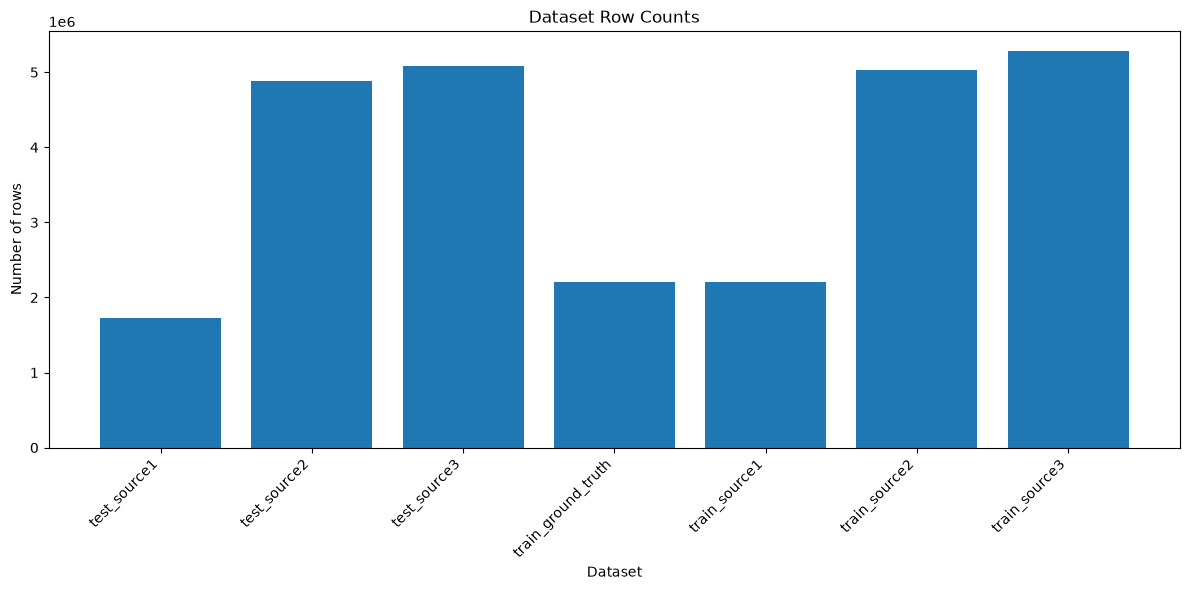

In [43]:
FIGURE_DIR = Path("../eda_outputs/figures")
FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(FIGURE_DIR.resolve())

plt.figure(figsize=(12, 6))

plt.bar(
    dataset_profile_df["dataset"],
    dataset_profile_df["row_count"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("Number of rows")
plt.xlabel("Dataset")
plt.title("Dataset Row Counts")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "dataset_row_counts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

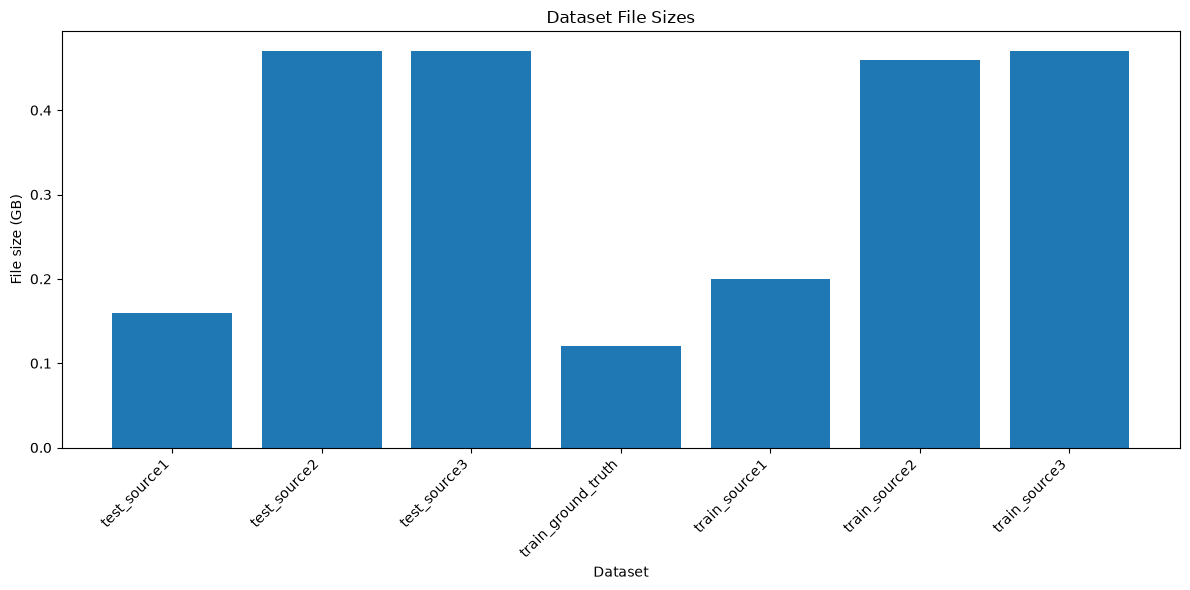

In [44]:
plt.figure(figsize=(12, 6))

plt.bar(
    dataset_profile_df["dataset"],
    dataset_profile_df["file_size_GB"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("File size (GB)")
plt.xlabel("Dataset")
plt.title("Dataset File Sizes")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "dataset_file_sizes.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Initial Findings

## 1. Dataset Scale

The supplied data consists of six source datasets and one ground-truth
dataset.

The exact row counts and file sizes are reported in the dataset profile
table above.

## 2. Source Dataset Structure

All source datasets use the following fields:

- `entity_id`
- `business_name`
- `business_address`
- `country`

The source datasets therefore share a common structural format.

## 3. Ground Truth Structure

The ground-truth dataset contains:

- `source1_entity_id`
- `matched_entity_ids`

The exact interpretation and formatting of `matched_entity_ids` will be
investigated further in the ground-truth EDA notebook.

## 4. Data Types

All currently inspected fields are represented as string values.

This is appropriate for entity-resolution analysis because identifiers,
business names, addresses, and country values are primarily textual fields.

## 5. Initial Data Quality

Sample-level null, empty-string, uniqueness, and identifier statistics
were calculated.

These are preliminary observations only. Full-data quality analysis will
be performed separately in `02_data_quality.ipynb`.

## 6. Computational Considerations

The datasets are large enough that full in-memory loading is not the
default strategy.

Large-scale operations should therefore use query-based or
streaming/lazy processing where appropriate, while samples can be used
for visualization and exploratory inspection.

# Dataset-Specific Observations

After inspecting the dataset samples and profiling results:

### `train_source1`

- Rows:
- Columns:
- File size:
- Schema:
- Initial observations:

### `train_source2`

- Rows:
- Columns:
- File size:
- Schema:
- Initial observations:

### `train_source3`

- Rows:
- Columns:
- File size:
- Schema:
- Initial observations:

### `train_ground_truth`

- Rows:
- Columns:
- File size:
- Schema:
- Initial observations:

### `test_source1`

- Rows:
- Columns:
- File size:
- Schema:
- Initial observations:

### `test_source2`

- Rows:
- Columns:
- File size:
- Schema:
- Initial observations:

### `test_source3`

- Rows:
- Columns:
- File size:
- Schema:
- Initial observations:

# Implications for the Entity Resolution Solution

The profiling results provide the following initial considerations for
the solution:

1. **Scale**

   The solution must be designed for large-scale data processing rather
   than relying on loading all datasets into memory simultaneously.

2. **Common source schema**

   The source datasets share the same core attributes:
   `entity_id`, `business_name`, `business_address`, and `country`.

3. **Entity attributes**

   Business name, address, and country are candidate attributes for
   determining whether records from different sources refer to the same
   real-world entity.

4. **Identifiers**

   `entity_id` identifies records within the source datasets and should
   not automatically be assumed to represent a globally shared identity
   across sources.

5. **Ground truth**

   The ground-truth mapping provides the supervised information required
   to investigate and evaluate entity matching.

6. **Data quality**

   Missing values, formatting inconsistencies, duplicate records, and
   attribute reliability need to be quantified before designing the
   final matching strategy.

7. **Next analysis**

   The next notebook will perform full-data data-quality analysis and
   identify the cleaning and normalization requirements that should be
   incorporated into the matching pipeline.